# Notebook 3 — RFM Segmentation & Revenue Risk Scoring
**Project:** E-commerce Customer Segmentation & Revenue Risk Scoring  
**Dataset:** UCI Online Retail II (2009–2011)  
**Author:** Pratiksha Dandriyal

---

## Objective
Segment all 5,878 customers using RFM (Recency, Frequency, Monetary) logic built entirely in pandas — no ML library. Then apply a rule-based churn risk score to identify customers whose historical spend is at risk.

## Why RFM?
EDA showed that top 20% of customers drive 77.2% of revenue. RFM helps us identify *which* customers sit in that top tier, *which* are slipping away, and *how much revenue* is at risk if we lose them.

## Steps
1. Compute R, F, M values per customer
2. Score each metric on a 1–4 scale using quartiles
3. Assign named segments based on score combinations
4. Visualise segment distribution and revenue
5. Build rule-based churn risk score
6. Quantify revenue at risk

---
## 1. Imports & settings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

GREEN  = '#1D9E75'
PURPLE = '#7F77DD'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
GRAY   = '#888780'
TEAL   = '#5DCAA5'

SEG_COLORS = {
    'Champions'     : '#1D9E75',
    'Loyal'         : '#5DCAA5',
    'Promising'     : '#7F77DD',
    'Need Attention': '#EF9F27',
    'At Risk'       : '#D85A30',
    'Lost'          : '#888780'
}

FILE_PATH  = r'C:\Users\prati_t686nlu\OneDrive\Desktop\clean_retail.csv'
OUTPUT_DIR = r'C:\Users\prati_t686nlu\OneDrive\Desktop'

---
## 2. Load clean data

In [2]:
df = pd.read_csv(FILE_PATH, parse_dates=['InvoiceDate'])

print(f'Shape      : {df.shape}')
print(f'Customers  : {df["Customer ID"].nunique():,}')
print(f'Date range : {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
df.head(3)

Shape      : (805549, 13)
Customers  : 5,878
Date range : 2009-12-01 to 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,Year,Month,YearMonth,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday


---
## 3. Compute R, F, M values

- **Recency** — days since the customer's last purchase (lower = better)
- **Frequency** — number of unique invoices (higher = better)
- **Monetary** — total spend across all orders (higher = better)

In [3]:
# Snapshot date = one day after the last transaction in the dataset
# This simulates 'today' so recency is calculated correctly
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('Customer ID').agg(
    last_purchase = ('InvoiceDate', 'max'),
    frequency     = ('Invoice',     'nunique'),
    monetary      = ('TotalRevenue','sum')
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

print(f'\nRFM table shape: {rfm.shape}')
print(f'\nDistribution summary:')
rfm[['recency','frequency','monetary']].describe().round(2)

Snapshot date: 2011-12-10

RFM table shape: (5878, 5)

Distribution summary:


,recency,frequency,monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62
std,209.34,13.01,14737.73
min,1.00,1.00,2.95
25%,26.00,1.00,348.76
50%,96.00,3.00,898.92
75%,380.00,7.00,2307.09
max,739.00,398.00,608821.65


---
## 4. Score each metric 1–4 using quartiles

Each metric is split into 4 equal groups (quartiles) and scored 1–4.
- For Recency: lower days = score 4 (recently purchased = good)
- For Frequency & Monetary: higher value = score 4

In [4]:
# Recency: lower days gets higher score (4 = most recent)
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1]).astype(int)

# Frequency & Monetary: rank first to handle ties, then qcut
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)

# Combined RFM string (e.g. '444' = best possible customer)
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print('Score distribution:')
print(f'R scores: {rfm["R_score"].value_counts().sort_index().to_dict()}')
print(f'F scores: {rfm["F_score"].value_counts().sort_index().to_dict()}')
print(f'M scores: {rfm["M_score"].value_counts().sort_index().to_dict()}')
print()
rfm[['Customer ID','recency','frequency','monetary','R_score','F_score','M_score','RFM_Score']].head(8)

Score distribution:
R scores: {1: 1459, 2: 1466, 3: 1443, 4: 1510}
F scores: {1: 1470, 2: 1469, 3: 1469, 4: 1470}
M scores: {1: 1470, 2: 1469, 3: 1469, 4: 1470}



,Customer ID,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
0,12346,326,12,77556.46,2,4,4,244
1,12347,2,8,5633.32,4,4,4,444
2,12348,75,5,2019.40,3,3,3,333
3,12349,19,4,4428.69,4,3,4,434
4,12350,310,1,334.40,2,1,1,211
5,12351,375,1,300.93,2,1,1,211
6,12352,36,10,2849.84,3,4,4,344
7,12353,204,2,406.76,2,2,2,222


---
## 5. Assign named segments

Score combinations are mapped to 6 business-meaningful segments using explicit rules — fully explainable to any stakeholder.

In [5]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'       # Recent, frequent, high spenders
    elif r >= 3 and f >= 2:
        return 'Loyal'           # Recent and fairly frequent
    elif r >= 3 and f == 1:
        return 'Promising'       # Recent but low frequency — new or occasional
    elif r == 2 and f >= 2:
        return 'Need Attention'  # Moderately recent, moderate frequency — fading
    elif r <= 2 and f >= 3:
        return 'At Risk'         # Was frequent, now gone quiet
    else:
        return 'Lost'            # Low recency, low frequency

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print('Segment distribution:')
print(rfm['Segment'].value_counts())
print()
rfm[['Customer ID','recency','frequency','monetary','R_score','F_score','M_score','Segment']].head(10)

Segment distribution:
Segment
Champions         1814
Lost              1595
Need Attention    1104
Loyal              803
Promising          336
At Risk            226
Name: count, dtype: int64



,Customer ID,recency,frequency,monetary,R_score,F_score,M_score,Segment
0,12346,326,12,77556.46,2,4,4,Need Attention
1,12347,2,8,5633.32,4,4,4,Champions
2,12348,75,5,2019.40,3,3,3,Champions
3,12349,19,4,4428.69,4,3,4,Champions
4,12350,310,1,334.40,2,1,1,Lost
5,12351,375,1,300.93,2,1,1,Lost
6,12352,36,10,2849.84,3,4,4,Champions
7,12353,204,2,406.76,2,2,2,Need Attention
8,12354,232,1,1079.40,2,1,3,Lost
9,12355,214,2,947.61,2,2,3,Need Attention


---
## 6. Visualise segments

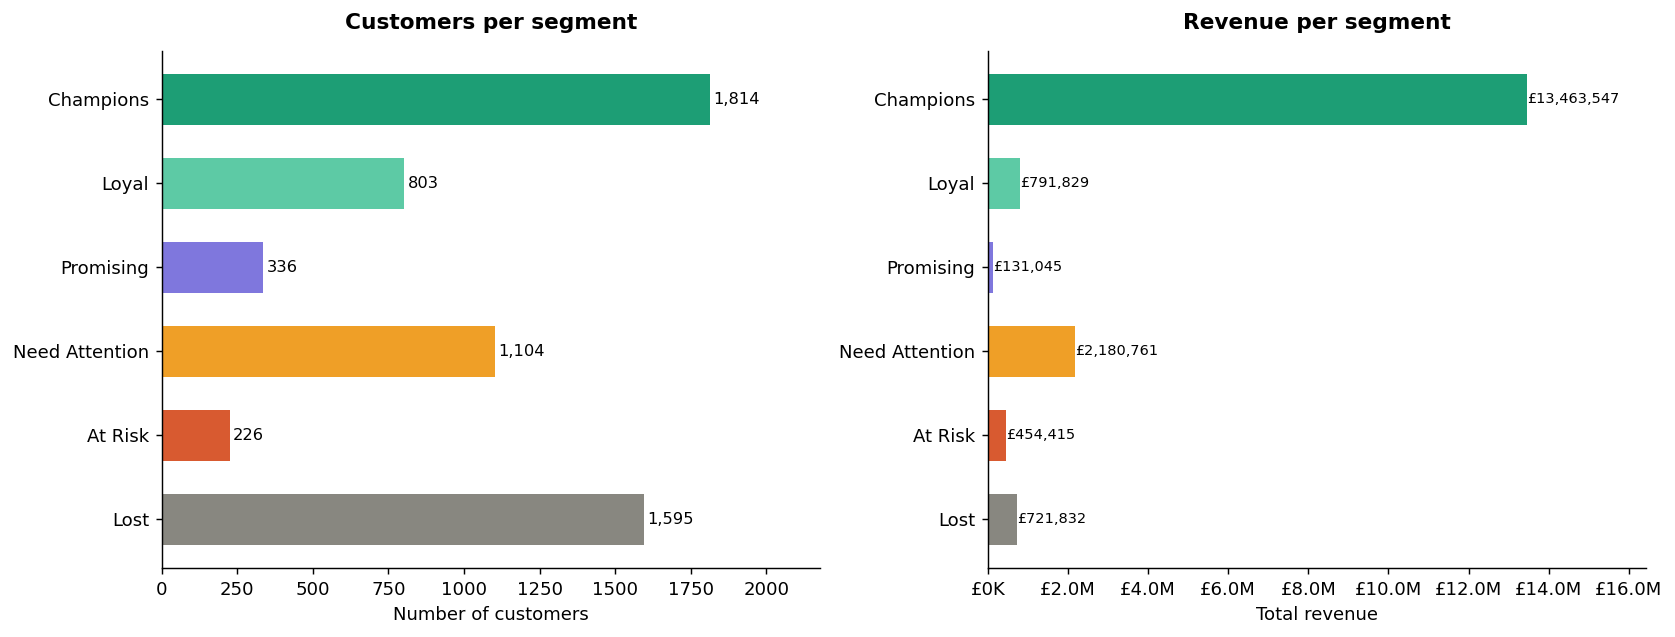

In [6]:
seg_order  = ['Champions','Loyal','Promising','Need Attention','At Risk','Lost']
seg_counts = rfm['Segment'].value_counts().reindex(seg_order)
seg_rev    = rfm.groupby('Segment')['monetary'].sum().reindex(seg_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Customer count per segment
ax1    = axes[0]
colors = [SEG_COLORS[s] for s in seg_order]
bars   = ax1.barh(seg_order[::-1], seg_counts[::-1], color=colors[::-1], height=0.6)
ax1.set_title('Customers per segment', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Number of customers')
for bar, val in zip(bars, seg_counts[::-1]):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlim(0, seg_counts.max() * 1.2)

# Chart 2: Revenue per segment
ax2  = axes[1]
bars = ax2.barh(seg_order[::-1], seg_rev[::-1], color=colors[::-1], height=0.6)
ax2.set_title('Revenue per segment', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Total revenue')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'\u00a3{x/1e6:.1f}M' if x >= 1e6 else f'\u00a3{x/1e3:.0f}K'))
for bar, val in zip(bars, seg_rev[::-1]):
    ax2.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'\u00a3{val:,.0f}', va='center', fontsize=8)
ax2.set_xlim(0, seg_rev.max() * 1.22)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\03_segment_distribution.png', bbox_inches='tight')
plt.show()

---
## 7. RFM heatmap — Recency vs Frequency coloured by avg Monetary

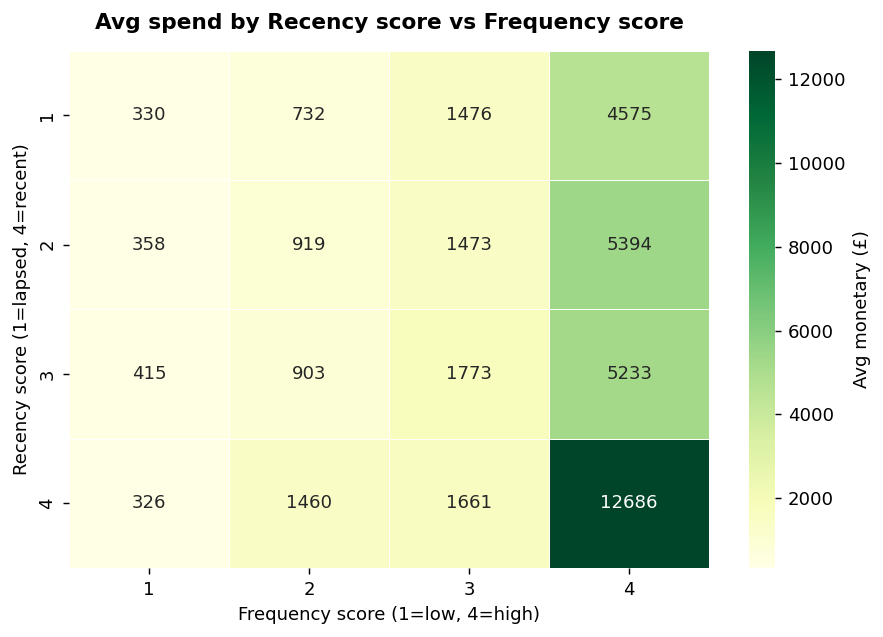

Bottom-right cell (R=1, F=4): high frequency but lapsed — these are your At Risk customers.


In [7]:
heatmap_data = rfm.groupby(['R_score','F_score'])['monetary'].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Avg monetary (\u00a3)'}
)
ax.set_title('Avg spend by Recency score vs Frequency score', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Frequency score (1=low, 4=high)')
ax.set_ylabel('Recency score (1=lapsed, 4=recent)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\03_rfm_heatmap.png', bbox_inches='tight')
plt.show()
print('Bottom-right cell (R=1, F=4): high frequency but lapsed — these are your At Risk customers.')

---
## 8. Rule-based churn risk scoring

**Logic:** A customer is flagged **High Risk** if they were a high-frequency buyer (F_score ≥ 3) but have not purchased in 90+ days.

This is fully rule-based — no ML, fully explainable to a business stakeholder.

In [8]:
rfm['churn_risk'] = 'Low'
rfm.loc[(rfm['recency'] >= 90) & (rfm['F_score'] >= 3), 'churn_risk'] = 'High'

high_risk    = rfm[rfm['churn_risk'] == 'High']
low_risk     = rfm[rfm['churn_risk'] == 'Low']
rev_at_risk  = high_risk['monetary'].sum()
total_rev    = rfm['monetary'].sum()

print(f'High risk customers : {len(high_risk):,}')
print(f'Low risk customers  : {len(low_risk):,}')
print(f'Revenue at risk     : \u00a3{rev_at_risk:,.0f}')
print(f'% of total revenue  : {rev_at_risk/total_rev*100:.1f}%')
print()
print('High risk breakdown by segment:')
print(rfm[rfm['churn_risk']=='High']['Segment'].value_counts())

High risk customers : 927
Low risk customers  : 4,951
Revenue at risk     : £2,340,625
% of total revenue  : 13.2%

High risk breakdown by segment:
Segment
Need Attention    654
At Risk           226
Champions          41
Loyal               6
Name: count, dtype: int64


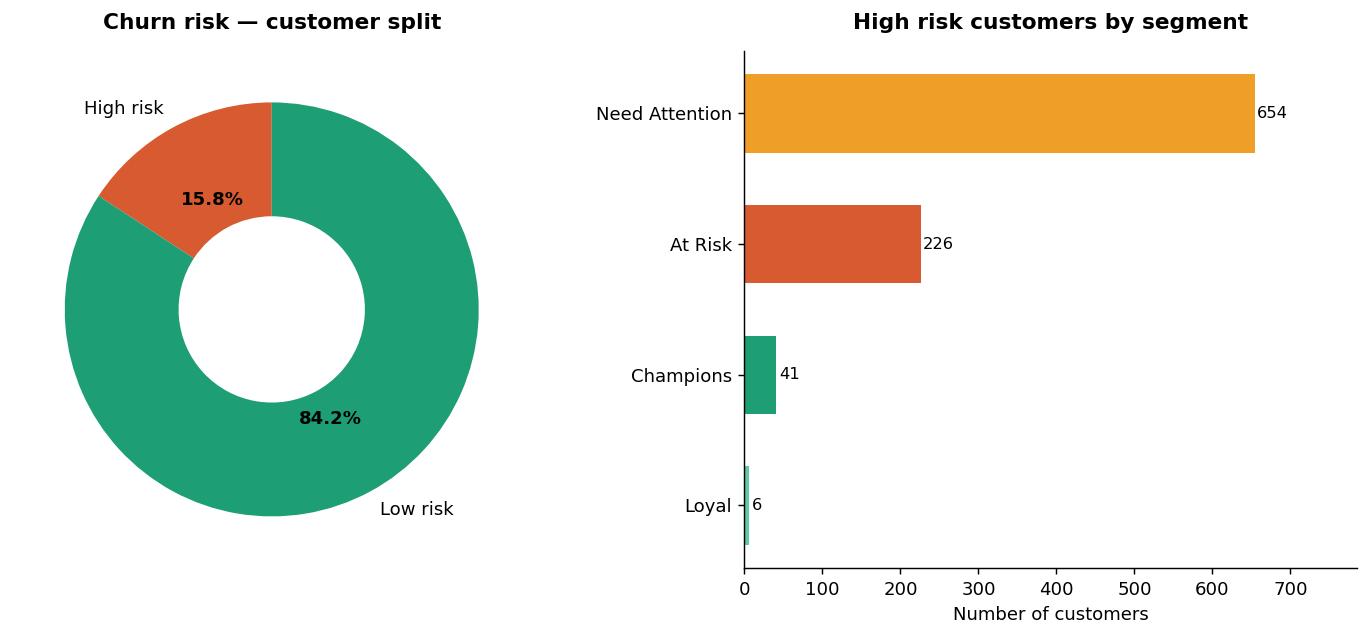

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Chart 1: High vs Low risk — customer count
ax1 = axes[0]
risk_counts = rfm['churn_risk'].value_counts()
wedges, texts, autotexts = ax1.pie(
    [risk_counts.get('High',0), risk_counts.get('Low',0)],
    labels=['High risk', 'Low risk'],
    colors=[CORAL, GREEN],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Churn risk — customer split', fontsize=12, fontweight='bold', pad=12)

# Chart 2: High risk customers per segment
ax2 = axes[1]
risk_by_seg  = rfm[rfm['churn_risk']=='High']['Segment'].value_counts()
seg_cols     = [SEG_COLORS.get(s, GRAY) for s in risk_by_seg.index]
bars         = ax2.barh(risk_by_seg.index[::-1], risk_by_seg.values[::-1],
                        color=seg_cols[::-1], height=0.6)
ax2.set_title('High risk customers by segment', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Number of customers')
for bar, val in zip(bars, risk_by_seg.values[::-1]):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax2.set_xlim(0, risk_by_seg.max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\03_churn_risk.png', bbox_inches='tight')
plt.show()

---
## 9. Final RFM table & export

In [10]:
rfm_final = rfm[['Customer ID','recency','frequency','monetary',
                 'R_score','F_score','M_score','RFM_Score','Segment','churn_risk']].copy()
rfm_final['monetary'] = rfm_final['monetary'].round(2)

rfm_final.to_csv(OUTPUT_DIR + r'\rfm_segments.csv', index=False)
print('Saved: rfm_segments.csv to Desktop')
print(f'Shape: {rfm_final.shape}')
rfm_final.head(10)

Saved: rfm_segments.csv to Desktop
Shape: (5878, 10)


,Customer ID,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score,Segment,churn_risk
0,12346,326,12,77556.46,2,4,4,244,Need Attention,High
1,12347,2,8,5633.32,4,4,4,444,Champions,Low
2,12348,75,5,2019.40,3,3,3,333,Champions,Low
3,12349,19,4,4428.69,4,3,4,434,Champions,Low
4,12350,310,1,334.40,2,1,1,211,Lost,Low
5,12351,375,1,300.93,2,1,1,211,Lost,Low
6,12352,36,10,2849.84,3,4,4,344,Champions,Low
7,12353,204,2,406.76,2,2,2,222,Need Attention,Low
8,12354,232,1,1079.40,2,1,3,213,Lost,Low
9,12355,214,2,947.61,2,2,3,223,Need Attention,Low


---
## 10. Project summary — all key findings

In [11]:
champions    = rfm[rfm['Segment'] == 'Champions']
champ_rev    = champions['monetary'].sum()
champ_pct    = champ_rev / total_rev * 100

print('='*55)
print('         FINAL PROJECT SUMMARY')
print('='*55)
print(f'Total customers analysed    : {len(rfm):>10,}')
print(f'Total revenue (2yr)         : \u00a3{total_rev:>10,.0f}')
print()
print('--- Segments ---')
for seg in seg_order:
    n   = (rfm['Segment'] == seg).sum()
    rev = rfm[rfm['Segment'] == seg]['monetary'].sum()
    print(f'  {seg:<18}: {n:>5,} customers  |  \u00a3{rev:>12,.0f}')
print()
print('--- Risk ---')
print(f'  High risk customers       : {len(high_risk):>10,}')
print(f'  Revenue at risk           : \u00a3{rev_at_risk:>10,.0f}  ({rev_at_risk/total_rev*100:.1f}% of total)')
print()
print('--- Anchor stats for interviews ---')
print(f'  Champions ({len(champions):,} customers) drive \u00a3{champ_rev:,.0f} ({champ_pct:.1f}% of revenue)')
print(f'  \u00a32,340,625 revenue at risk from {len(high_risk):,} high-churn-risk customers')
print('='*55)

         FINAL PROJECT SUMMARY
Total customers analysed    :      5,878
Total revenue (2yr)         : £17,743,429

--- Segments ---
  Champions         : 1,814 customers  |  £  13,463,547
  Loyal             :   803 customers  |  £     791,829
  Promising         :   336 customers  |  £     131,045
  Need Attention    : 1,104 customers  |  £   2,180,761
  At Risk           :   226 customers  |  £     454,415
  Lost              : 1,595 customers  |  £     721,832

--- Risk ---
  High risk customers       :        927
  Revenue at risk           : £ 2,340,625  (13.2% of total)

--- Anchor stats for interviews ---
  Champions (1,814 customers) drive £13,463,547 (75.9% of revenue)
  £2,340,625 revenue at risk from 927 high-churn-risk customers


---
## Notebook summary

| Segment | Customers | Revenue |
|---|---|---|
| Champions | 1,814 | £13,463,547 |
| Loyal | 803 | £791,829 |
| Promising | 336 | £131,045 |
| Need Attention | 1,104 | £2,180,761 |
| At Risk | 226 | £454,415 |
| Lost | 1,595 | £721,832 |

**Anchor stat:** £2,340,625 revenue at risk from 927 high-churn-risk customers (13.2% of total revenue)

**Interview line:** *"I built the churn risk score using pure business logic — if a customer was in the top frequency quartile but hasn't purchased in 90+ days, they are flagged high risk. No black-box model, fully explainable to any business stakeholder."*